In [3]:
x = 5
n = 25
for i in range(n):
    y = (3 * x) % 141
    x = y
    print(y)


15
45
135
123
87
120
78
93
138
132
114
60
39
117
69
66
57
30
90
129
105
33
99
15
45


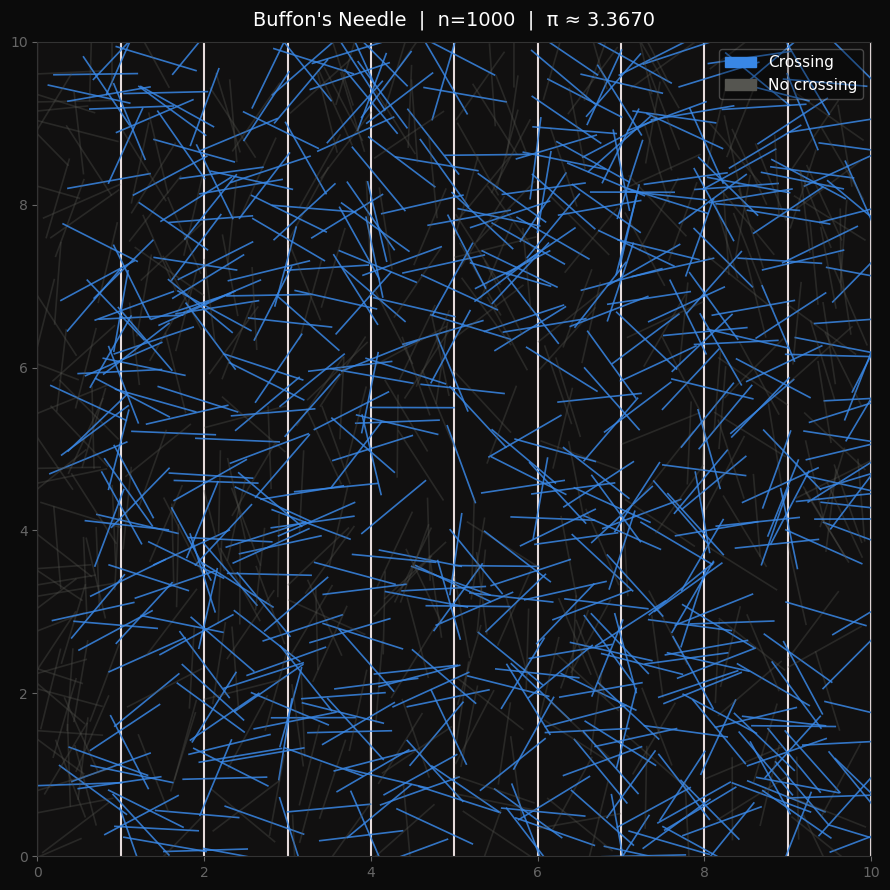

Runs: 1000 | Hits: 594 | π ≈ 3.36700


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use("dark_background")

n_runs = 1000
LINE_SPACING = 1.0
NEEDLE_L = 1.0

n_hits = 0
needles = []

for _ in range(n_runs):
    cx = np.random.uniform(0, 10)
    cy = np.random.uniform(0, 10)
    theta = np.random.uniform(0, np.pi)
    dx = (NEEDLE_L / 2) * np.cos(theta)
    dy = (NEEDLE_L / 2) * np.sin(theta)
    x1, x2 = cx - dx, cx + dx
    hit = int(x1 / LINE_SPACING) != int(x2 / LINE_SPACING)
    n_hits += hit
    needles.append((x1, cy - dy, x2, cy + dy, hit))

prob = n_hits / n_runs
pi_est = 2 / prob

fig, ax = plt.subplots(figsize=(9, 9), facecolor="#0B0B0B")
ax.set_facecolor("#111010")

# Floor lines
for x in np.arange(0, 11, LINE_SPACING):
    ax.axvline(x, color="#E6DCDC", linewidth=1.5, zorder=1)

# Needles
for (x1, y1, x2, y2, hit) in needles:
    color = "#0974F6" if hit else "rgba(160,160,150,0.4)"
    ax.plot([x1, x2], [y1, y2],
            color="#3987e5" if hit else "#555550",
            alpha=0.85 if hit else 0.35,
            linewidth=1.2, zorder=2)

# Legend
hit_patch   = mpatches.Patch(color="#3987e5", label="Crossing")
miss_patch  = mpatches.Patch(color="#555550", label="No crossing")
ax.legend(handles=[hit_patch, miss_patch], loc="upper right",
          fontsize=11, framealpha=0.3)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title(f"Buffon's Needle  |  n={n_runs}  |  π ≈ {pi_est:.4f}",
             fontsize=14, color="white", pad=12)
ax.tick_params(colors="#666")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("buffon_needle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Runs: {n_runs} | Hits: {n_hits} | π ≈ {pi_est:.5f}")

Total number of needles/runs:  400
Number of needles intersected:  255
Probability of intersection:  0.6375
pi:  3.1372549019607847


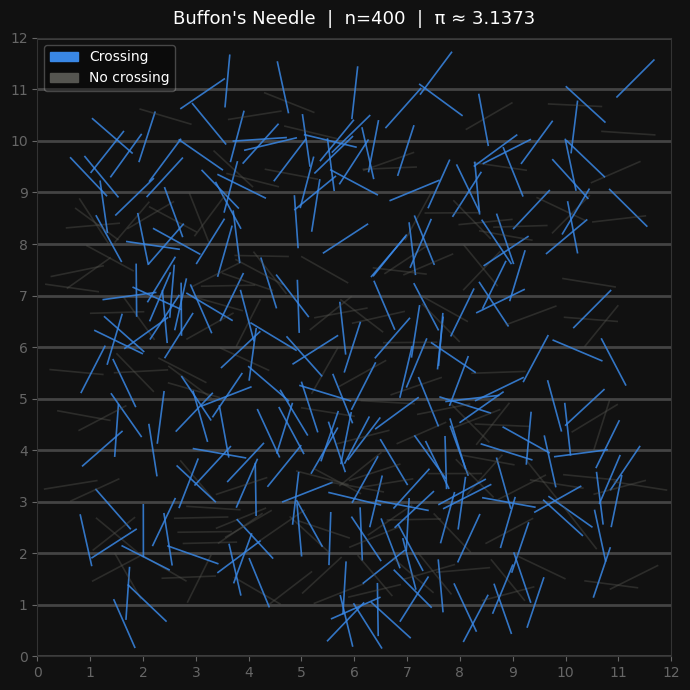

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use("dark_background")
n_runs = 400

n_hits = 0
xi, xj, yi, yj, colors = [], [], [], [], []

for i in range(n_runs):
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1
    theta = 2 * np.pi * np.random.rand()
    x2 = x1 + np.cos(theta)
    y2 = y1 + np.sin(theta)

    check = np.ceil(np.minimum(y1, y2)) == np.floor(np.maximum(y1, y2))
    n_hits += check
    
    xi.append(x1)
    xj.append(x2)
    yi.append(y1)
    yj.append(y2)
    colors.append("#3987e5" if check else "#555550")

prob = n_hits / n_runs
print('Total number of needles/runs: ', n_runs)
print('Number of needles intersected: ', n_hits)
print('Probability of intersection: ', prob)
print('pi: ', 2 / prob)

fig, ax = plt.subplots(figsize=[7, 7], facecolor="#111111")
ax.set_facecolor("#111111")

for i in range(n_runs):
    ax.plot([xi[i], xj[i]], [yi[i], yj[i]], color=colors[i],
            alpha=0.85 if colors[i] == "#3987e5" else 0.4, linewidth=1.2)

ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.set_xticks(range(13))
ax.set_yticks(range(13))
ax.yaxis.grid(True, linewidth=2, color="#444444")
ax.tick_params(colors="#666666")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

ax.set_title(f"Buffon's Needle  |  n={n_runs}  |  π ≈ {2/prob:.4f}",
             fontsize=13, color="white", pad=10)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#3987e5", label="Crossing"),
    mpatches.Patch(color="#555550", label="No crossing")
], fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.show()

Total number of needles/runs:  500
Number of needles intersected:  339
Probability of intersection:  0.678
pi:  2.949852507374631


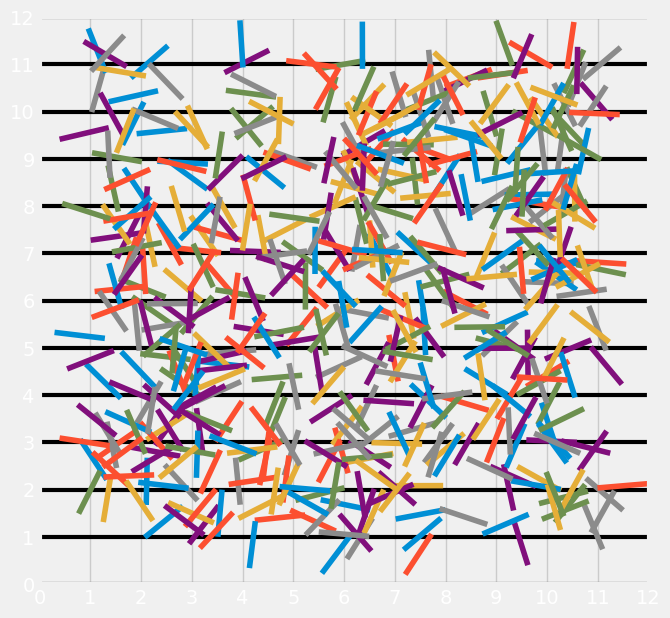

In [23]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image
plt.style.use("fivethirtyeight")
n_runs = 500

n_hits = 0
xi = []
xj = []
yi = []
yj = []
for i in range(n_runs):
    
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    theta = 2*np.pi * np.random.rand()

    x2 = x1 + np.cos(theta)
    y2 = y1 + np.sin(theta)

    check = np.ceil(np.minimum(y1, y2)) == np.floor(np.maximum(y1, y2))
    n_hits += check
    
    xi.append(x1)
    xj.append(x2)
    yi.append(y1)
    yj.append(y2)
prob = n_hits / n_runs
print('Total number of needles/runs: ', n_runs)
print('Number of needles intersected: ', n_hits)
print('Probability of intersection: ', prob)
print('pi: ', 2 / prob)
 
plt.figure(figsize=[7,7])
plt.plot([xi, xj], [yi, yj], '-')
plt.axis([0, 11, 0, 11])
plt.xticks(range(13))
plt.yticks(range(13))
plt.gca().yaxis.grid(True, linewidth=3, color="black")

Total number of needles/runs:  500
Number of needles intersected:  331
Probability of intersection:  0.662
pi:  3.021148036253776


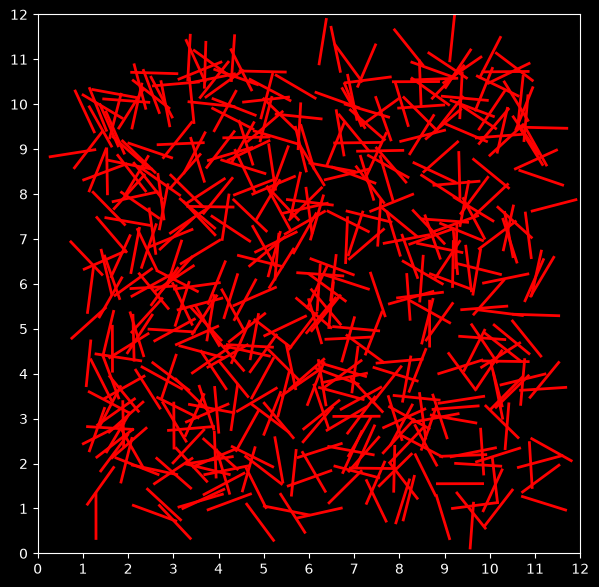

In [26]:
#my edit
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image
plt.style.use("dark_background")
n_runs = 500

n_hits = 0
xi = []
xj = []
yi = []
yj = []

for i in range(n_runs):

    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    theta = 2 * np.pi * np.random.rand()

    x2 = x1 + np.cos(theta)
    y2 = y1 + np.sin(theta)

    if np.ceil(min(y1, y2)) == np.floor(max(y1, y2)):
        n_hits += 1

    xi.append(x1)
    xj.append(x2)
    yi.append(y1)
    yj.append(y2)
    hits.append(check)
    
   
prob = n_hits / n_runs
print('Total number of needles/runs: ', n_runs)
print('Number of needles intersected: ', n_hits)
print('Probability of intersection: ', prob)
print('pi: ', 2 / prob)

plt.figure(figsize=[7,7])
for i in range(n_runs):
    if hits[i]:
        plt.plot([xi[i], xj[i]],
                 [yi[i], yj[i]],
                 color='red',
                 linewidth=2)
    else:
        plt.plot([xi[i], xj[i]],
                 [yi[i], yj[i]],
                 color='cyan',
                 linewidth=2)
plt.axis([0, 11, 0, 11])
plt.xticks(range(13))
plt.yticks(range(13))
plt.gca().yaxis.grid(True, linewidth=3, color="black")
 



In [3]:
#direct from chatgpt and edited
import numpy as np
import matplotlib.pyplot as plt

# For Jupyter Notebook
%matplotlib inline

plt.style.use("dark_background")
n_runs=500

n_hits = 0

xi = []
xj = []
yi = []
yj = []
hits = []

for _ in range(n_runs):

    # Random starting point
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    # Random angle
    theta = 2 * np.pi * np.random.rand()

    # Second endpoint
    x2 = x1 + needle_length * np.cos(theta)
    y2 = y1 + needle_length * np.sin(theta)

    # Check for intersection
    check = np.ceil(min(y1, y2)) == np.floor(max(y1, y2))

    n_hits += check

    xi.append(x1)
    yi.append(y1)
    xj.append(x2)
    yj.append(y2)
    hits.append(check)
    

# Probability and π estimate
prob = n_hits / n_runs
pi_est = 2 / prob

print("Total needles :", n_runs)
print("Intersections :", n_hits)
print("Probability   :", prob)
print("Estimated π   :", pi_est)

# ---------------- Plot ----------------

plt.figure(figsize=(9,9))

# Draw horizontal lines
for y in range(0,12):
    plt.axhline(y,
                color='white',
                linewidth=2)

# Draw needles
for i in range(n_runs):

    if hits[i]:
        color = "red"      # Hit
    else:
        color = "cyan"     # Miss

    plt.plot([xi[i], xj[i]],
             [yi[i], yj[i]],
             color=color,
             linewidth=1.8,
             alpha=0.8)

# Axes settings
plt.xlim(0,12)
plt.ylim(0,12)

plt.xticks(range(13))
plt.yticks(range(13))

plt.grid(True,
         linestyle="--",
         alpha=0.25)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Title
plt.title("Buffon's Needle Simulation",
          fontsize=18,
          fontweight="bold",
          pad=15,
          fontname="Georgia")

# Display π estimate
plt.text(
    0.5,
    11.3,
    f"Estimated π = {pi_est:.5f}",
    fontsize=12,
    color="yellow",
    bbox=dict(facecolor="black",
              edgecolor="yellow",
              alpha=0.8)
)

plt.show()

NameError: name 'needle_length' is not defined

Total Needles      : 400
Intersections      : 257
Probability        : 0.64250
Estimated π        : 3.112840
Actual π           : 3.141593


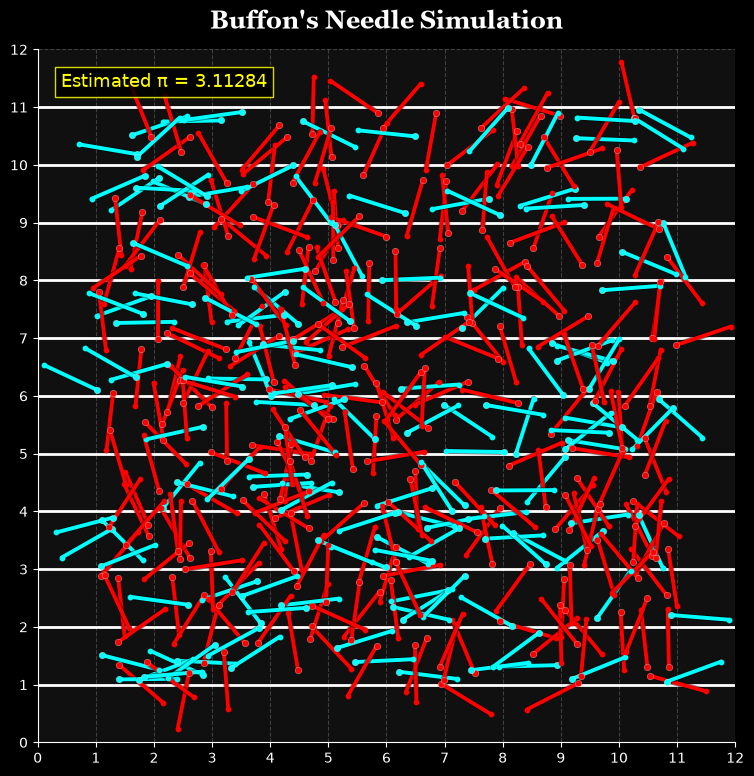

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Uncomment if using Jupyter Notebook
# %matplotlib inline

plt.style.use("dark_background")

# ---------------- Parameters ----------------

n_runs = 400
needle_length = 1

n_hits = 0

xi = []
yi = []
xj = []
yj = []
hits = []

# ---------------- Simulation ----------------

for _ in range(n_runs):

    # Random starting point
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    # Random angle
    theta = 2 * np.pi * np.random.rand()

    # Second endpoint
    x2 = x1 + needle_length * np.cos(theta)
    y2 = y1 + needle_length * np.sin(theta)

    # Check for intersection
    if np.ceil(min(y1, y2)) == np.floor(max(y1, y2)):
            n_hits += 1
            hits.append(True)
    else:
         hits.append(False)


    xi.append(x1)
    yi.append(y1)
    xj.append(x2)
    yj.append(y2)
    

# ---------------- Results ----------------

prob = n_hits / n_runs
pi_est = 2 / prob

print(f"Total Needles      : {n_runs}")
print(f"Intersections      : {n_hits}")
print(f"Probability        : {prob:.5f}")
print(f"Estimated π        : {pi_est:.6f}")
print(f"Actual π           : {np.pi:.6f}")

# ---------------- Plot ----------------

fig, ax = plt.subplots(figsize=(9,9))

ax.set_facecolor("#101010")

# Horizontal lines
for y in range(1,12):
    ax.axhline(y,
               color="white",
               linewidth=2)

# Draw needles
for i in range(n_runs):

    if hits[i]:
        needle_color = "red"
    else:
        needle_color = "cyan"

    # Shadow (gives depth)
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color="black",
            linewidth=4.2,
            alpha=0.45,
            solid_capstyle="round")

    # Metallic body
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color=needle_color,
            linewidth=2.8,
            solid_capstyle="round")

    # Needle eye
    ax.scatter(xi[i],
           yi[i],
           s=22,
           color=needle_color,
           edgecolors="white",
           linewidths=0.2,
           zorder=3)

    # Needle tip
    ax.scatter(xj[i],
               yj[i],
               s=10,
               color=needle_color,
               zorder=3)

# Axis settings
ax.set_xlim(0,12)
ax.set_ylim(0,12)

ax.set_xticks(range(13))
ax.set_yticks(range(13))

ax.grid(True,
        linestyle="--",
        alpha=0.20)

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Title
ax.set_title("Buffon's Needle Simulation",
             fontsize=18,
             fontweight="bold",
             pad=15,
             fontname="Georgia")

# Pi estimate box
ax.text(0.4,
        11.35,
        f"Estimated π = {pi_est:.5f}",
        fontsize=13,
        color="yellow",
        bbox=dict(facecolor="black",
                  edgecolor="yellow",
                  alpha=0.85))

plt.show()

In [3]:
%pip install matplotlib numpy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 7.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.5 MB 7.2 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 7.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 7.2 MB/s eta 0:00:01
   --------------- --------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Total Needles      : 400
Intersections      : 254
Probability        : 0.63500
Estimated π        : 3.149606
Actual π           : 3.141593


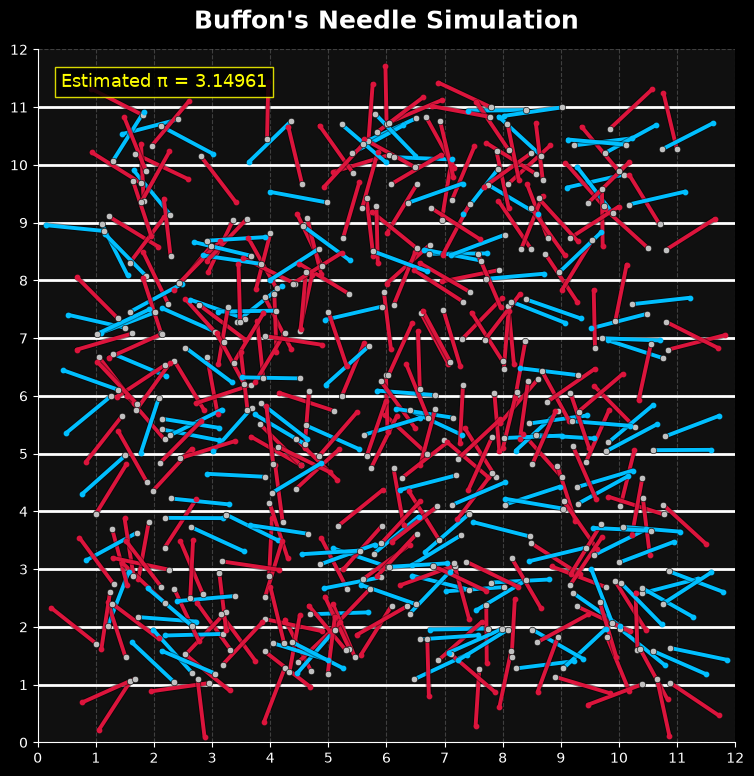

In [48]:
import numpy as np
import matplotlib.pyplot as plt
# Uncomment if using Jupyter Notebook
%matplotlib inline

plt.style.use("dark_background")

# ---------------- Parameters ----------------

n_runs = 400
needle_length = 1

n_hits = 0

xi = []
yi = []
xj = []
yj = []
hits = []

# ---------------- Simulation ----------------

for _ in range(n_runs):

    # Random starting point
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    # Random angle
    theta = 2 * np.pi * np.random.rand()

    # Second endpoint
    x2 = x1 + needle_length * np.cos(theta)
    y2 = y1 + needle_length * np.sin(theta)

    # Check for intersection
    if np.ceil(min(y1, y2)) == np.floor(max(y1, y2)):
        n_hits += 1
        hits.append(True)
    else:
        hits.append(False)

    xi.append(x1)
    yi.append(y1)
    xj.append(x2)
    yj.append(y2)

# ---------------- Results ----------------

prob = n_hits / n_runs
pi_est = 2 / prob

print(f"Total Needles      : {n_runs}")
print(f"Intersections      : {n_hits}")
print(f"Probability        : {prob:.5f}")
print(f"Estimated π        : {pi_est:.6f}")
print(f"Actual π           : {np.pi:.6f}")

# ---------------- Plot ----------------

fig, ax = plt.subplots(figsize=(9,9))

ax.set_facecolor("#101010")

# Horizontal lines
for y in range(1,12):
    ax.axhline(y,
               color="white",
               linewidth=2)

# Draw needles
for i in range(n_runs):

    if hits[i]:
        needle_color = "crimson"
    else:
        needle_color = "deepskyblue"

    # Shadow (gives depth)
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color="black",
            linewidth=4.2,
            alpha=0.45,
            solid_capstyle="round")

    # Metallic body
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color=needle_color,
            linewidth=2.8,
            solid_capstyle="round")

    # Needle eye
    ax.scatter(xi[i],
               yi[i],
               s=22,
               color="silver",
               edgecolors="black",
               linewidths=0.4,
               zorder=3)

    # Needle tip
    ax.scatter(xj[i],
               yj[i],
               s=10,
               color=needle_color,
               zorder=3)

# Axis settings
ax.set_xlim(0,12)
ax.set_ylim(0,12)

ax.set_xticks(range(13))
ax.set_yticks(range(13))

ax.grid(True,
        linestyle="--",
        alpha=0.20)

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Title
ax.set_title("Buffon's Needle Simulation",
             fontsize=18,
             fontweight="bold",
             pad=15)

# Pi estimate box
ax.text(0.4,
        11.35,
        f"Estimated π = {pi_est:.5f}",
        fontsize=13,
        color="yellow",
        bbox=dict(facecolor="black",
                  edgecolor="yellow",
                  alpha=0.85))

plt.show()

  Mean Estimate : 3.158681594139408
  Variance      : 0.011813175731991794
  Std Deviation : 0.10868843421446366
  Mean Absolute Error : 0.08378888545202551


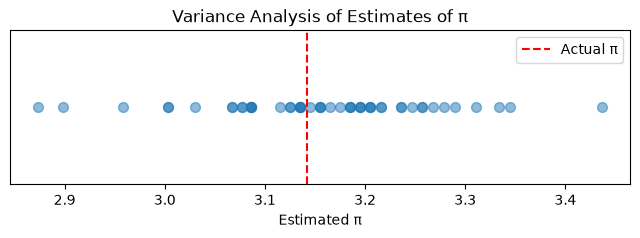

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_pi(n_runs):

    n_hits = 0

    for i in range(n_runs):

        x1 = 10*np.random.rand() + 1
        y1 = 10*np.random.rand() + 1

        theta = 2*np.pi*np.random.rand()

        x2 = x1 + np.cos(theta)
        y2 = y1 + np.sin(theta)

        if np.ceil(min(y1, y2)) == np.floor(max(y1, y2)):

            n_hits += 1

    prob = n_hits / n_runs
    estimated_pi = 2 / prob
 
    return estimated_pi
n_experiments = 50

pi_estimates = []
n_runs=500
for i in range(n_experiments):
    pi_estimates.append(estimate_pi(n_runs))

pi_estimates = np.array(pi_estimates)

mean_pi = np.mean(pi_estimates)

variance_pi = np.var(pi_estimates, ddof=1)   # Sample variance

std_pi = np.std(pi_estimates, ddof=1)
true_pi = np.pi

errors = np.abs(pi_estimates - true_pi)

mean_error = np.mean(errors)# Mean Absolute Error


print("  Mean Estimate :", mean_pi)
print("  Variance      :", variance_pi)
print("  Std Deviation :", std_pi)
print("  Mean Absolute Error :", mean_error)

plt.figure(figsize=(8,2))

plt.scatter(pi_estimates,
            np.ones(len(pi_estimates)),
            s=50,
            alpha=0.5)

plt.axvline(np.pi,
            color='red',
            linestyle='--',
            label='Actual π')

plt.yticks([])
plt.xlabel("Estimated π")
plt.title("Variance Analysis of Estimates of π")
plt.legend()

plt.show()

Total Needles      : 400
Intersections      : 245
Probability        : 0.61250
Estimated π        : 3.265306
Actual π           : 3.141593


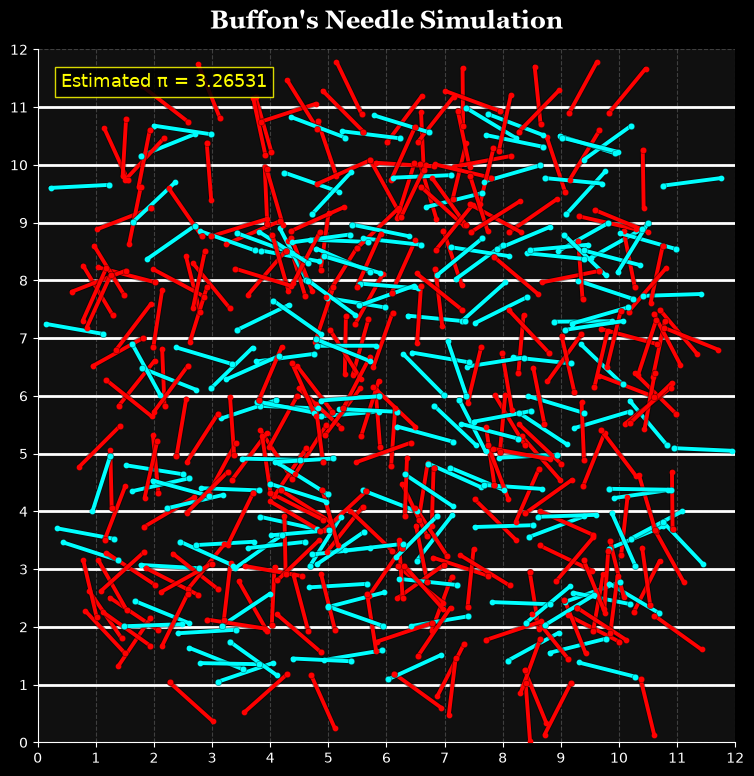

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Note : Uncomment if you're using Jupyter notebook
# %matplotlib inline

plt.style.use("dark_background")

n_runs = 400
needle_length = 1

n_hits = 0

xi = []
yi = []
xj = []
yj = []
hits = []

for _ in range(n_runs):

    # Random starting point
    x1 = 10 * np.random.rand() + 1
    y1 = 10 * np.random.rand() + 1

    # Random angle
    theta = 2 * np.pi * np.random.rand()

    # Second endpoint
    x2 = x1 + needle_length * np.cos(theta)
    y2 = y1 + needle_length * np.sin(theta)

    # Checking for intersection
    if np.ceil(min(y1, y2)) == np.floor(max(y1, y2)):
            n_hits += 1
            hits.append(True)
    else:
         hits.append(False)


    xi.append(x1)
    yi.append(y1)
    xj.append(x2)
    yj.append(y2)


prob = n_hits / n_runs
pi_est = 2 / prob

print(f"Total Needles      : {n_runs}")
print(f"Intersections      : {n_hits}")
print(f"Probability        : {prob:.5f}")
print(f"Estimated π        : {pi_est:.6f}")
print(f"Actual π           : {np.pi:.6f}")

# PLOT

fig, ax = plt.subplots(figsize=(9,9))

ax.set_facecolor("#101010")

# Horizontal lines
for y in range(1,12):
    ax.axhline(y,
               color="white",
               linewidth=2)

# Draw needles
for i in range(n_runs):

    if hits[i]:
        needle_color = "red"
    else:
        needle_color = "cyan"

    # Shadow (gives depth)
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color="black",
            linewidth=4.2,
            alpha=0.45,
            solid_capstyle="round")

    # Metallic body
    ax.plot([xi[i], xj[i]],
            [yi[i], yj[i]],
            color=needle_color,
            linewidth=2.8,
            solid_capstyle="round")

    # Needle eye
    ax.scatter(xi[i],
           yi[i],
           s=22,
           color=needle_color,
           edgecolors="black",
           linewidths=0.2,
           zorder=3)

    # Needle tip
    ax.scatter(xj[i],
               yj[i],
               s=10,
               color=needle_color,
               zorder=3)

# Axis settings
ax.set_xlim(0,12)
ax.set_ylim(0,12)

ax.set_xticks(range(13))
ax.set_yticks(range(13))

ax.grid(True,
        linestyle="--",
        alpha=0.20)

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Title
ax.set_title("Buffon's Needle Simulation",
             fontsize=18,
             fontweight="bold",
             pad=15,
             fontname="Georgia")

# Pi estimate box
ax.text(0.4,
        11.35,
        f"Estimated π = {pi_est:.5f}",
        fontsize=13,
        color="yellow",
        bbox=dict(facecolor="black",
                  edgecolor="yellow",
                  alpha=0.85))

plt.show()

Number of trials: 100000
Number of hits: 63715
Estimated value of pi: 3.138978262575532
Actual value of pi: 3.141592653589793
Absolute error: 0.002614391014261308


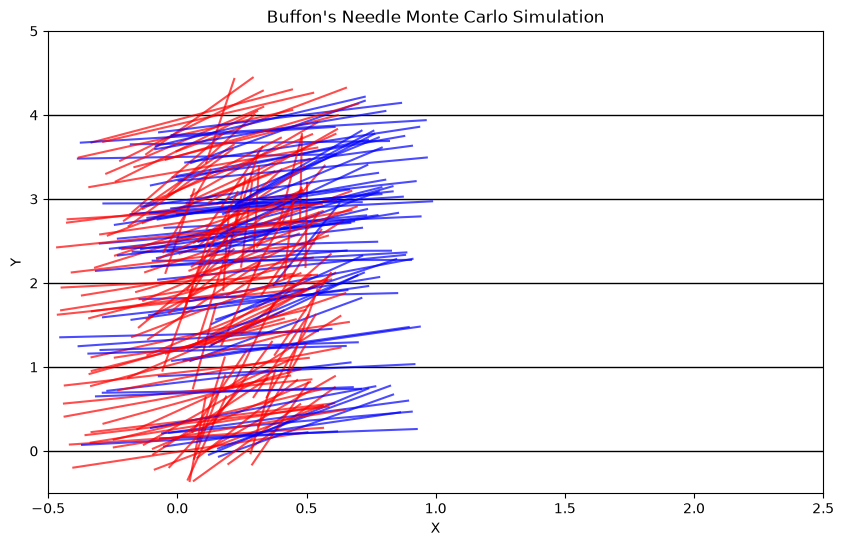

In [15]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

def buffon_needle_simulation(num_trials=10000, needle_length=1.0, line_spacing=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    hits = 0
    needle_data = []

    for _ in range(num_trials):
        # Needle center position
        x_center = random.uniform(0, line_spacing / 2)

        # Random orientation between 0 and pi/2
        theta = random.uniform(0, math.pi / 2)

        # Half needle projection on perpendicular axis
        half_projection = (needle_length / 2) * math.sin(theta)

        # Check if needle crosses a line
        hit = x_center <= half_projection
        if hit:
            hits += 1

        needle_data.append((x_center, theta, hit))

    if hits == 0:
        return None, needle_data

    pi_estimate = (2 * needle_length * num_trials) / (hits * line_spacing)
    return pi_estimate, needle_data


def plot_buffon_needles(needle_data, needle_length=1.0, line_spacing=1.0, max_plot=200):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw parallel lines
    for y in np.arange(0, 5 * line_spacing, line_spacing):
        ax.axhline(y, color="black", linewidth=1)

    # Plot a sample of needles
    for i, (x_center, theta, hit) in enumerate(needle_data[:max_plot]):
        y_center = random.uniform(0, 4 * line_spacing)
        dx = (needle_length / 2) * math.cos(theta)
        dy = (needle_length / 2) * math.sin(theta)

        x1, y1 = x_center - dx, y_center - dy
        x2, y2 = x_center + dx, y_center + dy

        color = "red" if hit else "blue"
        ax.plot([x1, x2], [y1, y2], color=color, alpha=0.7)

    ax.set_title("Buffon's Needle Monte Carlo Simulation")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_xlim(-0.5, needle_length + 1.5)
    ax.set_ylim(-0.5, 5 * line_spacing)
    plt.show()


if __name__ == "__main__":
    trials = 100000
    needle_length = 1.0
    line_spacing = 1.0

    pi_estimate, needle_data = buffon_needle_simulation(
        num_trials=trials,
        needle_length=needle_length,
        line_spacing=line_spacing,
        seed=42
    )

    print(f"Number of trials: {trials}")
    print(f"Number of hits: {sum(1 for _, _, hit in needle_data if hit)}")
    print(f"Estimated value of pi: {pi_estimate}")
    print(f"Actual value of pi: {math.pi}")
    print(f"Absolute error: {abs(pi_estimate - math.pi)}")

    plot_buffon_needles(needle_data, needle_length=needle_length, line_spacing=line_spacing)

In [2]:
x = 3
n = 50
for i in range(n):
    y = ((5 * x) + 7) % 200
    x = y
    print(y)


22
117
192
167
42
17
92
67
142
117
192
167
42
17
92
67
142
117
192
167
42
17
92
67
142
117
192
167
42
17
92
67
142
117
192
167
42
17
92
67
142
117
192
167
42
17
92
67
142
117


In [3]:
import random
a = []
for i in range(50):
    a.append(random.uniform(0, 1))
print(a)


[0.9427687283771572, 0.7114575929753332, 0.3455949166626314, 0.7760254757461404, 0.036650751435674866, 0.18474428881780192, 0.8454504997744136, 0.13424650302219787, 0.8459544162401476, 0.2919528572855995, 0.25425083114685576, 0.16035455142877753, 0.9420609160791237, 0.6431171014936481, 0.3445105822675335, 0.8439270038637735, 0.908668050010405, 0.6682461923991471, 0.1537535747395492, 0.4706140680828734, 0.5227900810821391, 0.555382203470046, 0.7068293181765674, 0.9064300128412648, 0.3149942547843436, 0.733657729951937, 0.7332326948169675, 0.26828265005980956, 0.8488516341476099, 0.7595962833584061, 0.5888431139008938, 0.7181914133163724, 0.9858870923307349, 0.35724350965759644, 0.056619396750770434, 0.05227690935138507, 0.8604196440479785, 0.4532375785224634, 0.5011453478050947, 0.4505226656646909, 0.7100821024764425, 0.5817680487238072, 0.9101216619959999, 0.7082453503869607, 0.4486676063152607, 0.5359801691154527, 0.010580596415816212, 0.7289403347477242, 0.4840391234980874, 0.4586607

In [4]:
import random
import pandas as pd

demand = [5, 6, 7, 8, 9, 10, 11, 12]
days = [4, 10, 16, 50, 62, 38, 12, 8]
totaldays = sum(days)

cummilativeprob = []
cprob = 0
for day in days:
    cprob += (day / totaldays)
    cummilativeprob.append(cprob)

rnum = []
for i in range(10):
    rnum.append(random.uniform(0, 1))

prediction = []
for num in rnum:
    predn = 0
    for i in range(len(cummilativeprob)):
        if num < cummilativeprob[i]:
            predn = demand[i]
            break
    prediction.append(predn)

print(cummilativeprob)
print(rnum)
print(prediction)

df = pd.DataFrame({
    "random values": rnum,
    "predictions(no.of cakes)": prediction
})
print(df)


[0.02, 0.07, 0.15000000000000002, 0.4, 0.71, 0.8999999999999999, 0.96, 1.0]
[0.9957480351468297, 0.8042486917382823, 0.9075217001696544, 0.46690996303026844, 0.3170898689649032, 0.14092316163399, 0.17324211997708938, 0.9611061060699682, 0.8905261526881928, 0.2397829497317352]
[12, 10, 11, 9, 8, 7, 8, 12, 10, 8]
   random values  predictions(no.of cakes)
0       0.995748                        12
1       0.804249                        10
2       0.907522                        11
3       0.466910                         9
4       0.317090                         8
5       0.140923                         7
6       0.173242                         8
7       0.961106                        12
8       0.890526                        10
9       0.239783                         8


In [5]:
if r <= p:
            predictions.append(demand[i])
            break

# Result table
df = pd.DataFrame({
    "Random Number": random_nums,
    "Predicted Demand": predictions
})

print(df)

SyntaxError: 'break' outside loop (4158226650.py, line 3)

In [6]:
items = ["apple", "banana", "orange", "apple", "mango"]
unq_items=set()

for obj in items:
    if obj in unq_items:
        print("duplicate is",obj)
    unq_items.add(obj)


duplicate is apple


In [15]:
import math
def circle(radius):
    area= math.pi*radius**2
    circumf=2*math.pi*radius
    return area,circumf
a,c=circle(5)
print("area is",a,"circumference",c)

area is 78.53981633974483 circumference 31.41592653589793


In [10]:
def sum_all(*args):
    print(args)
    for i in args:
        print(i*2)
    return sum(args)
sum_all(1,2,3,4) #in jupyter notebook return prints directly

(1, 2, 3, 4)
2
4
6
8


10

In [22]:
def keywords(**kwargs):
    for key,value in kwargs.items():
        print(f"{key}:{value}")

keywords(name="shaktiman",power="lazer")

name:shaktiman
power:lazer


In [2]:
n_hits=0
check = 5+5==10

n_hits += check
print(n_hits)

1


In [ ]:
if 5==10:
    return True

In [3]:
year=2025

if(year%4==0 and year%100!=0 or year%400==0):
    print("This is a leap year")
else:
    print("not a damn leap year")

not a damn leap year
